In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

import warnings

warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
output_dir = "/content/drive/MyDrive/imagenes_animacion"
os.makedirs(output_dir, exist_ok=True)

# Regular Matrix Transfer Method  (Abrupt temperature change)

In [ ]:
# =================================================================
# 1. PARÁMETROS DEL SISTEMA
# =================================================================

# Parámetros magnéticos
gamma = 2.8      # Proporción giromagnética (MHz/Oe)
H0 = 770.0       # Campo magnético aplicado (Oe)
deltaH = 0.5     # Ancho de línea FMR (Oe)

Delta_T = 6.0  # Gradiente de temperatura medido
alpha = 3.93   # Coeficiente térmico de magnetización del YIG (Gauss / K)

Ms_frio = 1750.0      # Magnetización de saturación base (Gauss)
Ms_caliente = Ms_frio - alpha * Delta_T  # Aproximación lineal de la modificación de la magnetización

# Frecuencias angulares (en rad/ns para consistencia con um y ns)
# Dividimos entre 1000 para pasar de MHz a GHz (1 / 1 GHz ~ 1 ns)
wH = 2 * np.pi * (gamma * H0 / 1000.0)
wM_frio = 2 * np.pi * (gamma * Ms_frio / 1000.0)
wM_caliente = 2 * np.pi * (gamma * Ms_caliente / 1000.0)

# Parámetros geométricos-ópticos
d = 8.3          # Espesor constante de la película plana
Lfrio = 170.0      # Longitud de la región oscura (fria)
Lcaliente = 230.0        # Longitud de la región iluminada (caliente)
Nperiods = 12    # Número total de períodos

In [ ]:
# =================================================================
# 2. FUNCIONES DE DISPERSIÓN Y ATENUACIÓN ESPACIAL
# =================================================================

def k_wave(w, wM):
    """Calcula el vector de onda real dado una frecuencia y una magnetización"""
    arg = 1 + (4 / wM**2) * (wH * (wH + wM) - w**2)
    # Evitar valores inválidos fuera de la banda de propagación
    if arg <= 0:
        return np.nan
    return -(1 / (2 * d)) * np.log(arg)

def v_group(w, wM):
    """Calcula la velocidad de grupo en um/ns"""
    k = k_wave(w, wM)
    return (wM**2 * d * np.exp(-2 * k * d)) / (4 * w)

def k_prime(w, wM):
    """Calcula la tasa de atenuación espacial k' en rad/um"""
    vg = np.abs(v_group(w, wM))

    # Dividimos entre 1000 para que quede  (rad / ns) / (um / ns) = rad / um
    # Al multiplicar por L en um nos queda el argumento de la exponencial en rad
    gamma_rad_ns = 2 * np.pi * (gamma * deltaH / 1000.0)
    return gamma_rad_ns / vg

In [ ]:
# =======================================================================
# 3. CONSTRUCCIÓN DE LAS MATRICES DE TRANSFERENCIA
# =======================================================================

def GammaRef(w):
    """Coeficiente de reflexión por salto de impedancia"""
    k_frio = k_wave(w, wM_frio)
    k_caliente = k_wave(w, wM_caliente)

    return  abs((k_frio - k_caliente) / (k_frio + k_caliente))

def T_interface(nu, w):
    """Matriz de interfaz geométrica. nu=+1 (entrada), nu=-1 (salida)"""
    mat = np.array([
        [1.0, nu * GammaRef(w)],
        [nu * GammaRef(w), 1.0]
    ], dtype=complex)
    return (1.0 / (1.0 - nu * GammaRef(w))) * mat

def T_prop(w, wM, L):
    """Matriz de propagación con atenuación intrínseca"""
    k = k_wave(w, wM)
    kp = k_prime(w, wM)

    # Acumulación de fase y decaimiento de amplitud
    exp_minus = np.exp(-(1j * k - kp) * L)
    exp_plus  = np.exp((1j * k - kp) * L)

    return np.array([
        [exp_minus, 0.0],
        [0.0, exp_plus]
    ], dtype=complex)

def T_cell(w):
    """Multiplicación de matrices para una Celda Unidad completa"""
    t_pf = T_prop(w, wM_frio, Lfrio)
    t_in = T_interface(1, w)
    t_g  = T_prop(w, wM_caliente, Lcaliente)
    t_out = T_interface(-1, w)
    # @ -> multiplicación de matrices en numpy
    return t_pf @ t_in @ t_g @ t_out

def transmission_power(f_GHz):
    """Coeficiente de potencia transmitida Pw para el cristal de N periodos"""
    w = 2 * np.pi * f_GHz
    tc = T_cell(w)
    # Matriz elevada a la potencia N
    T_total = np.linalg.matrix_power(tc, Nperiods)
    T11 = T_total[0, 0]
    return 1.0 / (np.abs(T11)**2)  # P_tr = 1 / |T_11|^2 = 1 / |T_22|^2

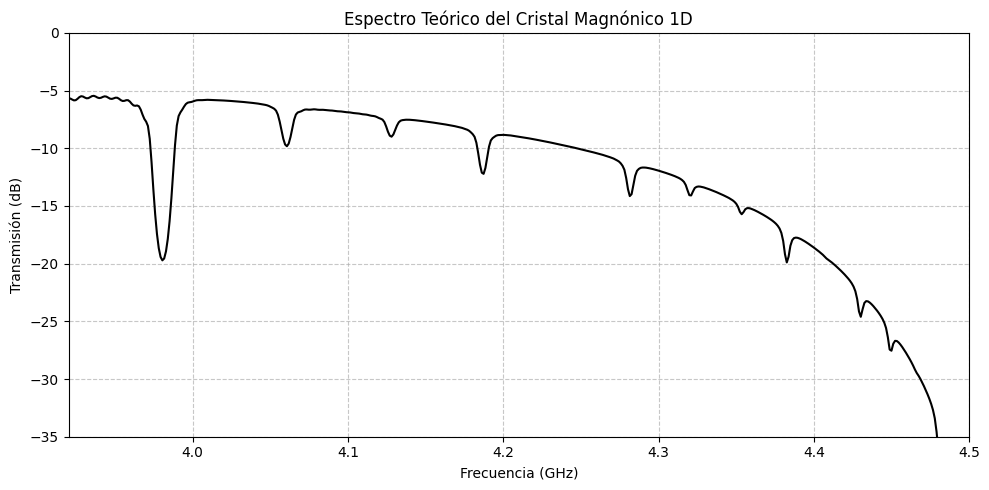

In [ ]:
# =================================================================
# 4. CÁLCULO DEL ESPECTRO
# =================================================================

# Rango de frecuencias
f_min_ghz = 3.92
f_max_ghz = 4.5
f_array = np.linspace(f_min_ghz, f_max_ghz, 500)
trans_db = []

# Evaluar numéricamente cada punto
for f in f_array:
    p_w = transmission_power(f)
    trans_db.append(10 * np.log10(p_w))  # Escala de potencia en decibeles


plt.figure(figsize=(10, 5))
plt.plot(f_array, trans_db, color='black', linewidth=1.5)
plt.title('Espectro Teórico del Cristal Magnónico 1D')
plt.xlabel('Frecuencia (GHz)')
plt.ylabel('Transmisión (dB)')
plt.xlim(f_min_ghz, f_max_ghz)
plt.ylim(-35, 0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Stratified Transfer Matrix Method (Continuous Change)

In [60]:
# =================================================================
# 1. PARÁMETROS DEL SISTEMA
# =================================================================

# Parámetros magnéticos
gamma = 2.8      # Proporción giromagnética (MHz/Oe)
H0 = 770.0      # Campo magnético aplicado (Oe)
deltaH = 0.5     # Ancho de línea FMR (Oe)

Delta_T = 6.0  # Pico de temperatura máximo
alpha = 3.93   # Coeficiente térmico de magnetización del YIG (Gauss / K)

Ms_frio = 1750.0      # Magnetización de saturación base (Gauss)
Ms_caliente = Ms_frio - alpha * Delta_T  # Aproximación lineal de la modificación de la magnetización

# Frecuencias angulares (en rad/ns para consistencia con um y ns)
# Dividimos entre 1000 para pasar de MHz a GHz (1 / 1 GHz ~ 1 ns)
wH = 2 * np.pi * (gamma * H0 / 1000.0)
wM_frio = 2 * np.pi * (gamma * Ms_frio / 1000.0)

# Parámetros geométricos-ópticos
d = 8.3          # Espesor constante de la película plana
Lfrio = 70.0      # Longitud de la región oscura (fria)
Lcaliente = 330.0        # Longitud de la región iluminada (caliente)
Lambda = Lfrio + Lcaliente   # Parámetro de red
Nperiods = 12    # Número total de períodos

# =================================================================
# PARÁMETROS DEL PERFIL GAUSSIANO (El control del calor)
# =================================================================

N_slices = 400  # Mayor resolución para capturar bien la campana
dx = Lambda / N_slices # longitud de cada rebanada

x_array = np.linspace(0, Lambda, N_slices, endpoint=False)
Ms_perfil = np.zeros(N_slices)

In [54]:
# Perfil continuo gaussiano
# Centro del haz láser (lo colocamos a la mitad de la franja iluminada)
x_centro = Lfrio + (Lcaliente / 2.0)
sigma_termal = 20.0 # Factor de termalización (sigma).
for i, x in enumerate(x_array):
    # Calculamos la distancia al centro del láser.
    # Usamos la distancia periódica para que las colas de calor se envuelvan
    # correctamente si el calor invade las celdas vecinas.
    distancia = np.abs(x - x_centro)
    distancia_periodica = np.minimum(distancia, Lambda - distancia)

    # Amplitud de la campana en este punto x (de 0.0 a 1.0)
    perfil_gauss = np.exp(- (distancia_periodica**2) / (2 * sigma_termal**2))

    # Mapeamos la amplitud térmica a la magnetización
    Ms_perfil[i] = Ms_frio - (Ms_frio - Ms_caliente) * perfil_gauss

In [5]:
# Perfil continuo cuadrado
for i, x in enumerate(x_array):
    if x <= 69:
      Ms_perfil[i] = Ms_frio
    else:
      Ms_perfil[i] = Ms_caliente

In [61]:
# GENERACIÓN DEL PERFIL SUPER-GAUSSIANO (Aproximación Cuadrada)

w = Lcaliente / 2.0  # El semiancho de la zona iluminada (15 um)
P = 30                # Orden P. Con P=20 será visualmente indistinguible de un cuadrado

for i, x in enumerate(x_array):
    distancia = np.abs(x - x_centro)
    distancia_periodica = np.minimum(distancia, Lambda - distancia)

    # La matemática del Super-Gaussiano
    perfil_super_gauss = np.exp(- (distancia_periodica / w)**(2 * P))

    # Mapeo a la magnetización
    Ms_perfil[i] = Ms_frio - (Ms_frio - Ms_caliente) * perfil_super_gauss

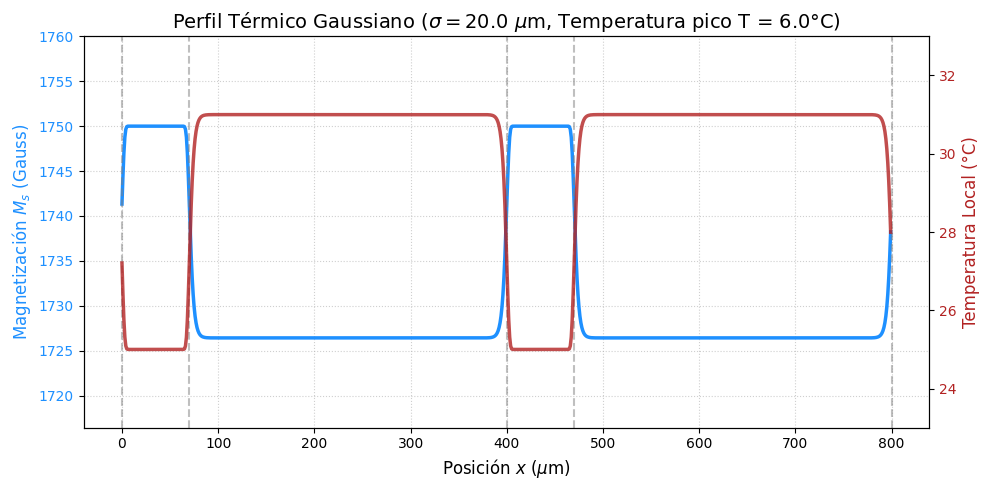

In [62]:
# =================================================================
# VISUALIZACIÓN DEL ARRAY GENERADO
# =================================================================

# Graficamos 2 celdas completas para ver la periodicidad
x_extendido = np.concatenate([x_array, x_array + Lambda])
Ms_extendido = np.concatenate([Ms_perfil, Ms_perfil])

# Calculamos el perfil térmico equivalente para el eje Y secundario
T_extendido = 25.0 + ((Ms_frio - Ms_extendido) / alpha) # Asumiendo T_amb = 25°C

fig, ax1 = plt.subplots(figsize=(10, 5))

# Eje principal: Magnetización (Ms)
color1 = 'dodgerblue'
ax1.plot(x_extendido, Ms_extendido, color=color1, linewidth=2.5)
ax1.set_xlabel('Posición $x$ ($\mu$m)', fontsize=12)
ax1.set_ylabel('Magnetización $M_s$ (Gauss)', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(Ms_caliente - 10, Ms_frio + 10)

# Eje secundario: Temperatura
ax2 = ax1.twinx()
color2 = 'firebrick'
ax2.plot(x_extendido, T_extendido, color=color2, linewidth=2.5, alpha=0.8)
ax2.set_ylabel('Temperatura Local (°C)', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(25.0 - 2, 25.0 + Delta_T + 2)

# Líneas guía de la estructura geométrica
for limite in [0, Lfrio, Lambda, Lambda + Lfrio, 2*Lambda]:
    ax1.axvline(x=limite, color='gray', linestyle='--', alpha=0.5)

plt.title(f'Perfil Térmico Gaussiano ($\sigma = {sigma_termal}\ \mu$m, Temperatura pico T = {Delta_T}°C)', fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [63]:
# =================================================================
# 2. FUNCIONES DE DISPERSIÓN Y ATENUACIÓN ESPACIAL LOCALES
# =================================================================

def w_M(Ms):
    """Frecuencia angular dada una magnetización Ms"""
    return 2 * np.pi * (gamma * Ms / 1000.0)

def k_wave(w, Ms):
    """Calcula el vector de onda real dado una frecuencia y una magnetización"""
    wM = w_M(Ms)
    arg = 1 + (4 / wM**2) * (wH * (wH + wM) - w**2)
    # Evitar valores inválidos fuera de la banda de propagación
    if arg <= 0:
        return np.nan
    return -(1 / (2 * d)) * np.log(arg)

def k_prime(w, Ms):
    """Calcula la tasa de atenuación espacial k' en rad/um"""
    # Primero calcula la velocidad de grupo en um/ns
    wM = w_M(Ms)
    k = k_wave(w, Ms)
    # Evitamos divergencias si k es puramente imaginario
    #if np.iscomplex(k) and np.real(k) == 0:
        #return 0.0
    vg = (wM**2 * d * np.exp(-2 * np.real(k) * d)) / (4 * w)

    # Dividimos entre 1000 para que quede  (rad / ns) / (um / ns) = rad / um
    # Al multiplicar por L en um nos queda el argumento de la exponencial en rad
    gamma_rad_ns = 2 * np.pi * (gamma * deltaH / 1000.0)
    return gamma_rad_ns / np.abs(vg)

# =================================================================
# FUNCIONES DE DISPERSIÓN: BVMSW (Modelo Vogel et al. 2015)
# =================================================================
def w_FMR_bvmsw(Ms):
    """ Frecuencia de Resonancia Ferromagnética """
    wm = w_M(Ms)
    return np.sqrt(wH * (wH + wm))

def vg_bvmsw(Ms):
    """ Velocidad de Grupo (Aproximación lineal) """
    wm = w_M(Ms)
    w_fmr = w_FMR_bvmsw(Ms)
    return -(1.0 / 4.0) * (wH * wm / w_fmr) * d

def k_wave_bvmsw(w, Ms):
    """ Vector de onda local (Despeje lineal) """
    w_fmr = w_FMR_bvmsw(Ms)
    vg = vg_bvmsw(Ms)
    # BVMSW existe para frecuencias w < w_FMR
    if w >= w_fmr:
        return 0.0 + 1j * 10.0
    return (w - w_fmr) / vg

def k_prime_bvmsw(w, Ms):
    """ Factor de atenuación intrínseca """
    vg = vg_bvmsw(Ms)
    gamma_rad_ns = 2 * np.pi * (gamma * deltaH / 1000.0)
    return gamma_rad_ns / np.abs(vg)

In [64]:
# =================================================================
# 3. MATRICES ESTRATIFICADAS (Modelo de reflexión por Impedancia)
# =================================================================

def T_interface(Gamma):
    """Matriz de interfaz geométrica. nu=+1 (entrada), nu=-1 (salida)"""
    mat = np.array([
        [1.0, Gamma],
        [Gamma, 1.0]
        ], dtype=complex)
    return (1.0 / (1.0 - Gamma)) * mat

def T_cell_stratified_impedance(w, Ms_profile, dx):
    """
    Construye la matriz de la celda unidad multiplicando las N rebanadas
    usando la analogía de línea de transmisión (salto de impedancia).
    """
    N_slices = len(Ms_profile)
    T_total = np.eye(2, dtype=complex) # Matriz Identidad inicial

    for j in range(N_slices):
        Ms_curr = Ms_profile[j]
        k_curr = k_wave(w, Ms_curr)
        kp_curr = k_prime(w, Ms_curr)

        # 1. Matriz de propagación a través de la rebanada actual

        # Acumulación de fase y decaimiento de amplitud
        exp_minus = np.exp(-(1j * k_curr - kp_curr) * dx)
        exp_plus  = np.exp((1j * k_curr - kp_curr) * dx)

        T_prop = np.array([
            [exp_minus, 0.0],
            [0.0, exp_plus]
        ], dtype=complex)

        # 2. Matriz de interfaz
        # El índice circular (j+1) % N_slices conecta el final con el inicio de la celda
        Ms_next = Ms_profile[(j + 1) % N_slices]  # valor siguiente de magnetización
        k_next = k_wave(w, Ms_next)

        # Cálculo del coeficiente de reflexión local (desacople de vectores de onda)
        # Se añade un pequeño epsilon para evitar división por cero accidental
        Gamma = (k_curr - k_next) / (k_curr + k_next)

        T_int = T_interface(Gamma)

        # 3. Multiplicación de matrices

        T_total = T_total @ T_prop @ T_int

    return T_total

def transmission_power(f_GHz, Ms_profile, dx):
    """Coeficiente de potencia transmitida Pw para el cristal de N periodos"""
    w = 2 * np.pi * f_GHz
    tc = T_cell_stratified_impedance(w, Ms_profile, dx)
    # Matriz elevada a la potencia N
    T_total = np.linalg.matrix_power(tc, Nperiods)
    T11 = T_total[0, 0]
    return 1.0 / (np.abs(T11)**2)  # P_tr = 1 / |T_11|^2 = 1 / |T_22|^2

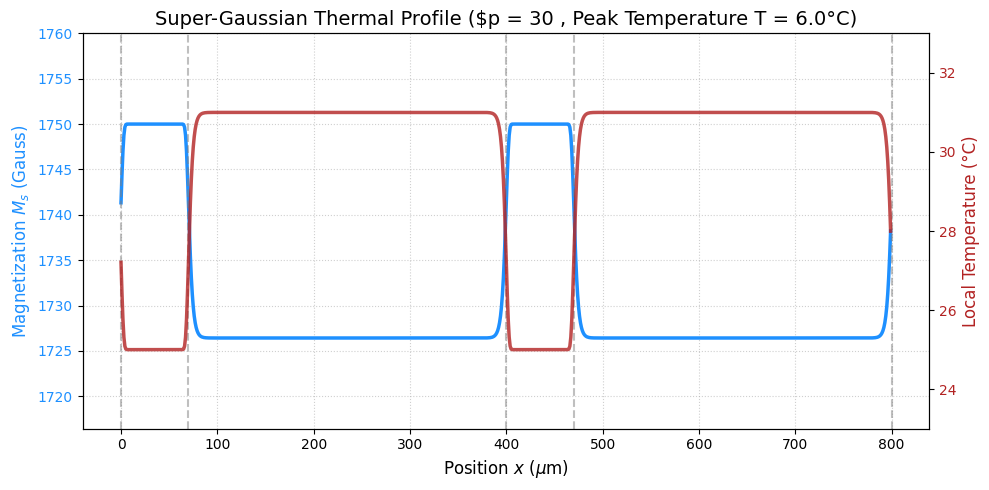

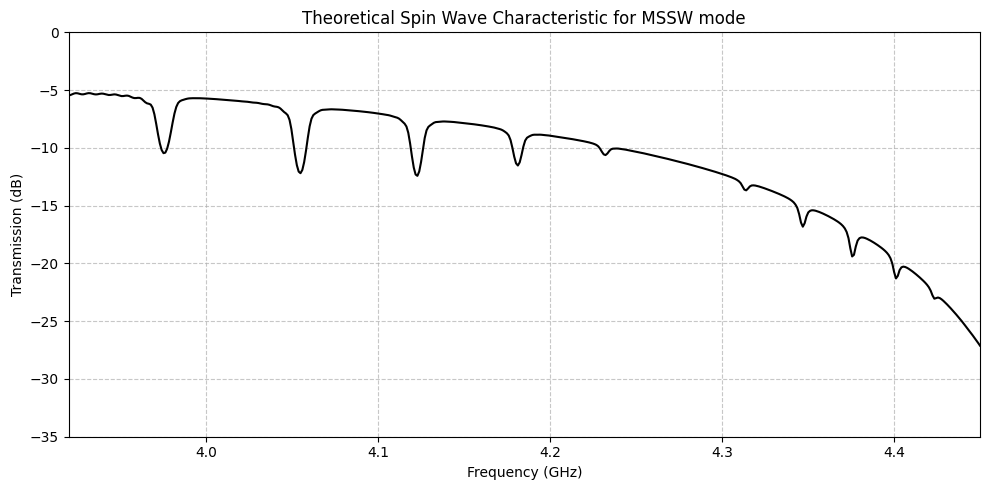

In [69]:
# =================================================================
# 4. EVALUACIÓN DEL ESPECTRO DE TRANSMISIÓN
# =================================================================

#f_min_ghz = 6.5
#f_max_ghz = 7.05

# Rango de frecuencias
f_min_ghz = 3.92
f_max_ghz = 4.45

f_array = np.linspace(f_min_ghz, f_max_ghz, 500)
trans_db = [] # transmitancias en decibeles

# Evaluar numéricamente cada False
for f in f_array:
    p_w = transmission_power(f, Ms_perfil, dx)
    trans_db.append(10 * np.log10(p_w))  # Escala de potencia en decibeles


# =================================================================
# VISUALIZACIÓN DEL ARRAY GENERADO
# =================================================================

# Graficamos 2 celdas completas para ver la periodicidad
x_extendido = np.concatenate([x_array, x_array + Lambda])
Ms_extendido = np.concatenate([Ms_perfil, Ms_perfil])

# Calculamos el perfil térmico equivalente para el eje Y secundario
T_extendido = 25.0 + ((Ms_frio - Ms_extendido) / alpha) # Asumiendo T_amb = 25°C

fig, ax1 = plt.subplots(figsize=(10, 5))

# Eje principal: Magnetización (Ms)
color1 = 'dodgerblue'
ax1.plot(x_extendido, Ms_extendido, color=color1, linewidth=2.5)
ax1.set_xlabel('Position $x$ ($\mu$m)', fontsize=12)
ax1.set_ylabel('Magnetization $M_s$ (Gauss)', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(Ms_caliente - 10, Ms_frio + 10)

# Eje secundario: Temperatura
ax2 = ax1.twinx()
color2 = 'firebrick'
ax2.plot(x_extendido, T_extendido, color=color2, linewidth=2.5, alpha=0.8)
ax2.set_ylabel('Local Temperature (°C)', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(25.0 - 2, 25.0 + Delta_T + 2)

# Líneas guía de la estructura geométrica
for limite in [0, Lfrio, Lambda, Lambda + Lfrio, 2*Lambda]:
    ax1.axvline(x=limite, color='gray', linestyle='--', alpha=0.5)

plt.title(f'Super-Gaussian Thermal Profile ($p = {P} , Peak Temperature T = {Delta_T}°C)', fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# =================================================================
# 4. VISUALIZACIÓN DEL ESPECTRO DE TRANSMISIÓN
# =================================================================

plt.figure(figsize=(10, 5))
plt.plot(f_array, trans_db, color='black', linewidth=1.5)
plt.title('Theoretical Spin Wave Characteristic for MSSW mode')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Transmission (dB)')
plt.xlim(f_min_ghz, f_max_ghz)
plt.ylim(-35, 0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
for s in range(31):  # de 0 a 30
    fig = mi_funcion(s)
    filename = os.path.join(output_dir, f"frame_{s:03d}.png")
    fig.savefig(filename, dpi=150, bbox_inches="tight")
    plt.close(fig)


def generar_figura(s, output_dir):

    # Crear figura
    fig, ax = plt.subplots(figsize=(6,4))

    # ---- TU CÓDIGO DE DIBUJO ----
    x = np.linspace(0, 2*np.pi, 500)
    y = np.sin(x + s/5)

    ax.plot(x, y)
    ax.set_title(f"s = {s}")
    ax.grid(True)
    # -----------------------------

    # Nombre del archivo
    filename = os.path.join(output_dir, f"frame_{s:03d}.png")

    # Guardar imagen
    fig.savefig(filename, dpi=150, bbox_inches='tight')

    # Cerrar figura para liberar memoria
    plt.close(fig)

for s in range(31):
    generar_figura(s, output_dir)


def mi_grafica(s, output_dir):

    fig, ax = plt.subplots()

    x = np.linspace(0,10,100)
    y = np.sin(s*x)

    ax.plot(x,y)
    ax.set_title(f"s={s}")

    filename = os.path.join(output_dir, f"frame_{s:03d}.png")

    fig.savefig(filename)

    plt.close(fig)

In [ ]:
# =================================================================
# 1. PARÁMETROS DEL SISTEMA (Vogel et al., 2015, Nature Physics)
# =================================================================
gamma = 2.8           # Proporción giromagnética (MHz/Oe)
H0 = 1797.0           # Campo magnético aplicado (Oe) equivalente a 143 kA/m
wH = 2 * np.pi * (gamma * H0 / 1000.0) # Frecuencia angular en rad/ns
d = 8.3               # Grosor de la película de YIG (um)
deltaH = 0.5          # Ancho de línea asumido (Oe)

# Geometría de la red
Lambda = 400.0        # Constante de red (um)
Nperiods = 5          # Número de franjas láser

# Parámetros Térmicos
T_background = 309.0  # Temperatura de fondo en la zona del cristal (K)
T_peak = 335.0        # Temperatura máxima en los picos (K)
Delta_T = T_peak - T_background # Salto térmico (K)

# Función de Magnetización de Saturación dependiente de la temperatura (en Gauss)
# 1759.3 G es la magnetización a 298 K. 3.93 es el coeficiente de decaimiento en Gauss/K
def Ms_T(T):
    return 1759.3 - 3.93 * (T - 298.0)


# Stratified Transfer Matrix Method For BVSW

In [46]:
# =================================================================
# 1. PARÁMETROS DEL SISTEMA
# =================================================================

# Parámetros magnéticos
gamma = 2.8      # Proporción giromagnética (MHz/Oe)
H0 = 770.0       # Campo magnético aplicado (Oe)
deltaH = 0.5     # Ancho de línea FMR (Oe)

Delta_T = 6.0  # Pico de temperatura máximo
alpha = 3.93   # Coeficiente térmico de magnetización del YIG (Gauss / K)

Ms_frio = 1750.0      # Magnetización de saturación base (Gauss)
Ms_caliente = Ms_frio - alpha * Delta_T  # Aproximación lineal de la modificación de la magnetización

# Frecuencias angulares (en rad/ns para consistencia con um y ns)
# Dividimos entre 1000 para pasar de MHz a GHz (1 / 1 GHz ~ 1 ns)
wH = 2 * np.pi * (gamma * H0 / 1000.0)
wM_frio = 2 * np.pi * (gamma * Ms_frio / 1000.0)

# Parámetros geométricos-ópticos
d = 6.3          # Espesor constante de la película plana
Lfrio = 70.0      # Longitud de la región oscura (fria)
Lcaliente = 330.0        # Longitud de la región iluminada (caliente)
Lambda = Lfrio + Lcaliente   # Parámetro de red
Nperiods = 12    # Número total de períodos

# =================================================================
# PARÁMETROS DEL PERFIL GAUSSIANO (El control del calor)
# =================================================================

N_slices = 400  # Mayor resolución para capturar bien la campana
dx = Lambda / N_slices # longitud de cada rebanada

x_array = np.linspace(0, Lambda, N_slices, endpoint=False)
Ms_perfil = np.zeros(N_slices)

In [38]:
# Perfil continuo gaussiano
# Centro del haz láser (lo colocamos a la mitad de la franja iluminada)
x_centro = Lfrio + (Lcaliente / 2.0)
sigma_termal = 20.0 # Factor de termalización (sigma).
for i, x in enumerate(x_array):
    # Calculamos la distancia al centro del láser.
    # Usamos la distancia periódica para que las colas de calor se envuelvan
    # correctamente si el calor invade las celdas vecinas.
    distancia = np.abs(x - x_centro)
    distancia_periodica = np.minimum(distancia, Lambda - distancia)

    # Amplitud de la campana en este punto x (de 0.0 a 1.0)
    perfil_gauss = np.exp(- (distancia_periodica**2) / (2 * sigma_termal**2))

    # Mapeamos la amplitud térmica a la magnetización
    Ms_perfil[i] = Ms_frio - (Ms_frio - Ms_caliente) * perfil_gauss

In [12]:
# Perfil continuo cuadrado
for i, x in enumerate(x_array):
    if x <= 69:
      Ms_perfil[i] = Ms_frio
    else:
      Ms_perfil[i] = Ms_caliente

In [47]:
# GENERACIÓN DEL PERFIL SUPER-GAUSSIANO (Aproximación Cuadrada)

w = Lcaliente / 2.0  # El semiancho de la zona iluminada (15 um)
P = 10                # Orden P. Con P=20 será visualmente indistinguible de un cuadrado

for i, x in enumerate(x_array):
    distancia = np.abs(x - x_centro)
    distancia_periodica = np.minimum(distancia, Lambda - distancia)

    # La matemática del Super-Gaussiano
    perfil_super_gauss = np.exp(- (distancia_periodica / w)**(2 * P))

    # Mapeo a la magnetización
    Ms_perfil[i] = Ms_frio - (Ms_frio - Ms_caliente) * perfil_super_gauss

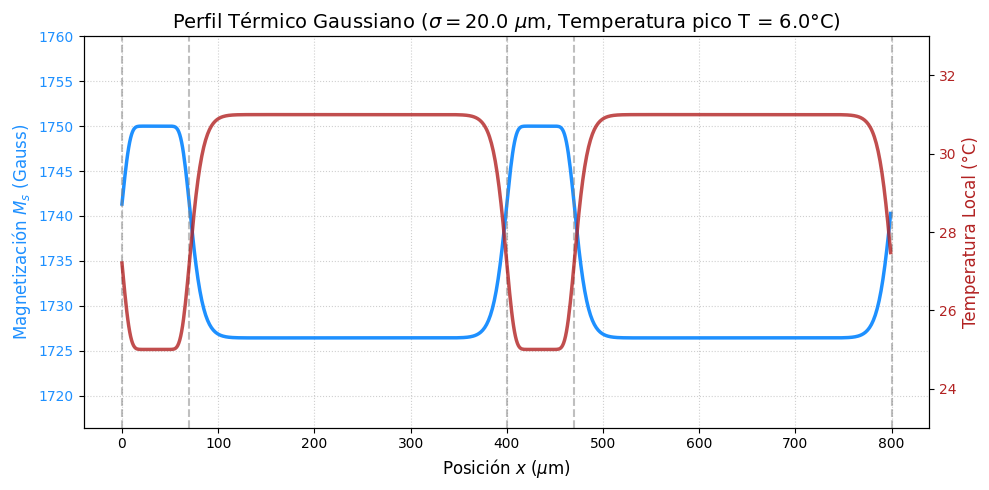

In [48]:
# =================================================================
# VISUALIZACIÓN DEL ARRAY GENERADO
# =================================================================

# Graficamos 2 celdas completas para ver la periodicidad
x_extendido = np.concatenate([x_array, x_array + Lambda])
Ms_extendido = np.concatenate([Ms_perfil, Ms_perfil])

# Calculamos el perfil térmico equivalente para el eje Y secundario
T_extendido = 25.0 + ((Ms_frio - Ms_extendido) / alpha) # Asumiendo T_amb = 25°C

fig, ax1 = plt.subplots(figsize=(10, 5))

# Eje principal: Magnetización (Ms)
color1 = 'dodgerblue'
ax1.plot(x_extendido, Ms_extendido, color=color1, linewidth=2.5)
ax1.set_xlabel('Posición $x$ ($\mu$m)', fontsize=12)
ax1.set_ylabel('Magnetización $M_s$ (Gauss)', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(Ms_caliente - 10, Ms_frio + 10)

# Eje secundario: Temperatura
ax2 = ax1.twinx()
color2 = 'firebrick'
ax2.plot(x_extendido, T_extendido, color=color2, linewidth=2.5, alpha=0.8)
ax2.set_ylabel('Temperatura Local (°C)', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(25.0 - 2, 25.0 + Delta_T + 2)

# Líneas guía de la estructura geométrica
for limite in [0, Lfrio, Lambda, Lambda + Lfrio, 2*Lambda]:
    ax1.axvline(x=limite, color='gray', linestyle='--', alpha=0.5)

plt.title(f'Perfil Térmico Gaussiano ($\sigma = {sigma_termal}\ \mu$m, Temperatura pico T = {Delta_T}°C)', fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [49]:
# =================================================================
# 3. FUNCIONES DE DISPERSIÓN: BVMSW (Modelo Vogel et al. 2015)
# =================================================================
def w_M(Ms):
    return 2 * np.pi * (gamma * Ms / 1000.0)

def w_FMR_bvmsw(Ms):
    """ Frecuencia de Resonancia Ferromagnética """
    wm = w_M(Ms)
    return np.sqrt(wH * (wH + wm))

def vg_bvmsw(Ms):
    """ Velocidad de Grupo (Aproximación lineal) """
    wm = w_M(Ms)
    w_fmr = w_FMR_bvmsw(Ms)
    return -(1.0 / 4.0) * (wH * wm / w_fmr) * d

def k_wave_bvmsw(w, Ms):
    """ Vector de onda local (Despeje lineal) """
    w_fmr = w_FMR_bvmsw(Ms)
    vg = vg_bvmsw(Ms)
    # BVMSW existe para frecuencias w < w_FMR
    if w >= w_fmr:
        return 0.0 + 1j * 10.0
    return (w - w_fmr) / vg

def k_prime_bvmsw(w, Ms):
    """ Factor de atenuación intrínseca """
    vg = vg_bvmsw(Ms)
    gamma_rad_ns = 2 * np.pi * (gamma * deltaH / 1000.0)
    return gamma_rad_ns / np.abs(vg)

In [50]:
# =================================================================
# 3. MATRICES ESTRATIFICADAS (Modelo de reflexión por Impedancia)
# =================================================================

def T_interface(Gamma):
    """Matriz de interfaz geométrica. nu=+1 (entrada), nu=-1 (salida)"""
    mat = np.array([
        [1.0, Gamma],
        [Gamma, 1.0]
        ], dtype=complex)
    return (1.0 / (1.0 - Gamma)) * mat

def T_cell_stratified_impedance(w, Ms_profile, dx):
    """
    Construye la matriz de la celda unidad multiplicando las N rebanadas
    usando la analogía de línea de transmisión (salto de impedancia).
    """
    N_slices = len(Ms_profile)
    T_total = np.eye(2, dtype=complex) # Matriz Identidad inicial

    for j in range(N_slices):
        Ms_curr = Ms_profile[j]
        k_curr = k_wave_bvmsw(w, Ms_curr)
        kp_curr = k_prime_bvmsw(w, Ms_curr)*0


        exp_minus = np.exp(-(1j * k_curr - kp_curr) * dx)
        exp_plus  = np.exp((1j * k_curr - kp_curr) * dx)

        T_prop = np.array([
            [exp_minus, 0.0],
            [0.0, exp_plus]
        ], dtype=complex)

        Ms_next = Ms_profile[(j + 1) % N_slices]
        k_next = k_wave_bvmsw(w, Ms_next)

        Gamma = (k_curr - k_next) / (k_curr + k_next)
        T_int = T_interface(Gamma)

        T_total = T_total @ T_prop @ T_int

    return T_total

def transmission_power(f_GHz, Ms_profile, dx):
    """Coeficiente de potencia transmitida Pw para el cristal de N periodos"""
    w = 2 * np.pi * f_GHz
    tc = T_cell_stratified_impedance(w, Ms_profile, dx)
    # Matriz elevada a la potencia N
    T_total = np.linalg.matrix_power(tc, Nperiods)
    T11 = T_total[0, 0]
    return 1.0 / (np.abs(T11)**2)  # P_tr = 1 / |T_11|^2 = 1 / |T_22|^2

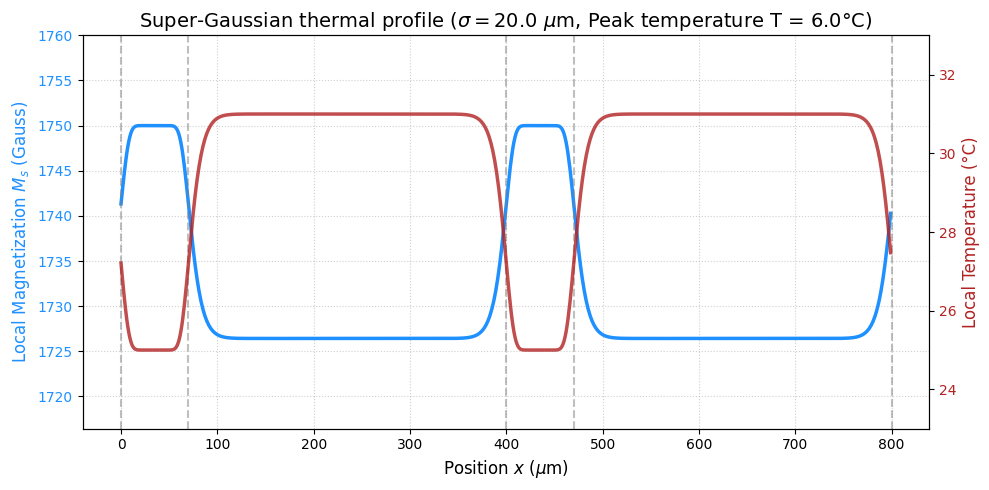

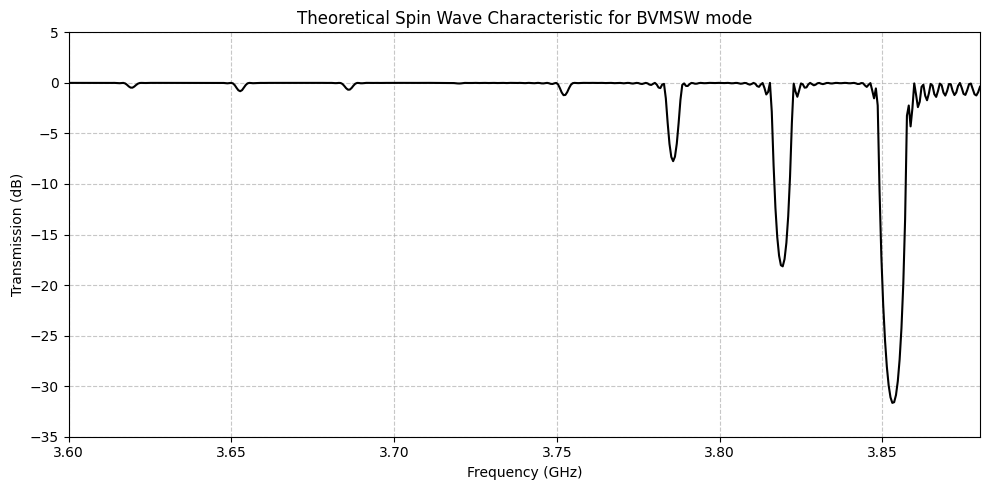

In [52]:
# =================================================================
# 4. EVALUACIÓN DEL ESPECTRO DE TRANSMISIÓN
# =================================================================

# Rango de frecuencias
f_min_ghz = 3.6
f_max_ghz = 3.88
f_array = np.linspace(f_min_ghz, f_max_ghz, 500)
trans_db = [] # transmitancias en decibeles

# Evaluar numéricamente cada False
for f in f_array:
    p_w = transmission_power(f, Ms_perfil, dx)
    trans_db.append(10 * np.log10(p_w))  # Escala de potencia en decibeles


# =================================================================
# VISUALIZACIÓN DEL ARRAY GENERADO
# =================================================================

# Graficamos 2 celdas completas para ver la periodicidad
x_extendido = np.concatenate([x_array, x_array + Lambda])
Ms_extendido = np.concatenate([Ms_perfil, Ms_perfil])

# Calculamos el perfil térmico equivalente para el eje Y secundario
T_extendido = 25.0 + ((Ms_frio - Ms_extendido) / alpha) # Asumiendo T_amb = 25°C

fig, ax1 = plt.subplots(figsize=(10, 5))

# Eje principal: Magnetización (Ms)
color1 = 'dodgerblue'
ax1.plot(x_extendido, Ms_extendido, color=color1, linewidth=2.5)
ax1.set_xlabel('Position $x$ ($\mu$m)', fontsize=12)
ax1.set_ylabel('Local Magnetization $M_s$ (Gauss)', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(Ms_caliente - 10, Ms_frio + 10)

# Eje secundario: Temperatura
ax2 = ax1.twinx()
color2 = 'firebrick'
ax2.plot(x_extendido, T_extendido, color=color2, linewidth=2.5, alpha=0.8)
ax2.set_ylabel('Local Temperature (°C)', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(25.0 - 2, 25.0 + Delta_T + 2)

# Líneas guía de la estructura geométrica
for limite in [0, Lfrio, Lambda, Lambda + Lfrio, 2*Lambda]:
    ax1.axvline(x=limite, color='gray', linestyle='--', alpha=0.5)

plt.title(f'Super-Gaussian thermal profile ($\sigma = {sigma_termal}\ \mu$m, Peak temperature T = {Delta_T}°C)', fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# =================================================================
# 4. VISUALIZACIÓN DEL ESPECTRO DE TRANSMISIÓN
# =================================================================

plt.figure(figsize=(10, 5))
plt.plot(f_array, trans_db, color='black', linewidth=1.5)
plt.title('Theoretical Spin Wave Characteristic for BVMSW mode')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Transmission (dB)')
plt.xlim(f_min_ghz, f_max_ghz)
plt.ylim(-35, 5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()